## 특허데이터 전처리

In [3]:
 import pandas as pd

# 1. 두 개의 원본 데이터 불러오기
# (경로는 작업 환경에 맞게 수정하세요. 예: Colab의 경우 '/content/raw_data...')

file_path1 = '/content/raw_data_검색식1.xlsx'
file_path2 = '/content/raw_data_검색식2.xlsx'

df1 = pd.read_excel(file_path1)
df2 = pd.read_excel(file_path2)

# 2. 데이터 병합 (단순 합치기)
df_combined = pd.concat([df1, df2], ignore_index=True)
print(f"✅ 병합 직후 전체 데이터 수: {len(df_combined)}건")

# 3. 중복 데이터 제거 (출원번호 기준)
# 검색식 1과 2의 교집합에 해당하는(양쪽에 다 검색된) 특허들의 중복을 제거합니다.
df_dedup = df_combined.drop_duplicates(subset=['출원번호'], keep='first').reset_index(drop=True)
print(f"✅ 중복 제거 후 데이터 수: {len(df_dedup)}건")

# 4. 토픽 모델링용 핵심 컬럼만 추출
# 텍스트 원문(요약), 시계열 분석용(출원일), 메타데이터(발명의 명칭, 출원인, 국가코드 등)
target_columns = ['국가코드', '출원번호', '출원일', '발명의 명칭', '요약', '출원인']

# 실제 데이터에 존재하는 컬럼만 안전하게 필터링
available_columns = [col for col in target_columns if col in df_dedup.columns]
df_clean = df_dedup[available_columns].copy()

# 5. 결측치(빈칸) 정제
# '요약(초록)' 텍스트가 없거나 '출원일'이 없는 데이터는 DTM 분석이 불가능하므로 삭제합니다.
df_clean = df_clean.dropna(subset=['요약', '출원일']).reset_index(drop=True)

# 시계열 분석을 위해 '출원일' 포맷을 datetime으로 통일 (에러 방지용)
df_clean['출원일'] = pd.to_datetime(df_clean['출원일'], errors='coerce')
df_clean = df_clean.dropna(subset=['출원일']).reset_index(drop=True)

print(f"✅ 결측치 제거 후 최종 분석용 데이터 수: {len(df_clean)}건")

# 6. 최종 정제된 데이터를 새로운 CSV 파일로 저장
output_filename = 'filtered_patent_data_ready.csv'
df_clean.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"🚀 전처리 완료! '{output_filename}' 파일이 성공적으로 저장되었습니다.")

✅ 병합 직후 전체 데이터 수: 2596건
✅ 중복 제거 후 데이터 수: 1865건
✅ 결측치 제거 후 최종 분석용 데이터 수: 1865건
🚀 전처리 완료! 'filtered_patent_data_ready.csv' 파일이 성공적으로 저장되었습니다.


## 논문데이터 전처리

In [16]:
# 1. 엑셀(.xls) 파일을 읽기 위한 라이브러리 설치
!pip install xlrd

In [17]:
import pandas as pd
import glob
import os

# 파일 목록 확인 (현재 폴더에 있는 모든 .csv 혹은 .xls 관련 파일)
file_list = glob.glob("culturedmeat_study*")

def read_excel_binary(file_path):
    try:
        # csv가 아닌 excel로 읽기 시도 (xls 형식 대응)
        df = pd.read_excel(file_path, engine='xlrd')

        # 컬럼명 정리
        df.columns = [str(c).strip() for c in df.columns]

        # 핵심 컬럼 찾기 (TI: 제목, AB: 초록, PY: 연도)
        title_col = next((c for c in df.columns if any(k in c.upper() for k in ['TITLE', 'TI'])), None)
        abs_col = next((c for c in df.columns if any(k in c.upper() for k in ['ABSTRACT', 'AB'])), None)
        year_col = next((c for c in df.columns if any(k in c.upper() for k in ['YEAR', 'PY'])), None)

        if abs_col and year_col:
            cols_to_keep = [title_col, abs_col, year_col] if title_col else [abs_col, year_col]
            res = df[cols_to_keep].copy()
            res.columns = ['Title', 'Abstract', 'Year'] if title_col else ['Abstract', 'Year']
            print(f"✅ {os.path.basename(file_path)} 읽기 성공! ({len(res)}건)")
            return res
        else:
            print(f"⚠️ {os.path.basename(file_path)}에서 컬럼을 찾지 못함. (컬럼: {df.columns[:5]})")
            return None
    except Exception as e:
        print(f"❌ {os.path.basename(file_path)} 처리 실패: {e}")
        return None

if not file_list:
    print("파일이 없습니다. 파일명을 확인해주세요.")
else:
    print("엑셀 데이터 병합 시작...")
    all_papers = [read_excel_binary(f) for f in file_list]
    valid_papers = [d for d in all_papers if d is not None]

    if not valid_papers:
        print("🛑 합칠 수 있는 유효한 데이터가 없습니다.")
    else:
        df_papers = pd.concat(valid_papers, ignore_index=True)

        # [데이터 품질 필터링] 배양육 관련 키워드 추출
        keywords = ['cultur', 'meat', 'cell', 'muscle', 'in vitro', 'bioreactor', 'scaffold']
        pattern = '|'.join(keywords)
        df_papers = df_papers[df_papers['Abstract'].str.contains(pattern, case=False, na=False)]

        # 연도 정리 및 중복 제거
        df_papers['Year'] = pd.to_numeric(df_papers['Year'], errors='coerce').fillna(0).astype(int)
        df_papers = df_papers[df_papers['Year'] > 1990].drop_duplicates().reset_index(drop=True)

        print(f"\n🚀 최종 정제 완료! 분석 대상 논문 수: {len(df_papers)}건")
        df_papers.to_csv("final_paper_data.csv", index=False, encoding='utf-8-sig')
        print("💾 'final_paper_data.csv' 저장 완료!")

엑셀 데이터 병합 시작...
✅ culturedmeat_study_4001_5000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_3001_4000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_1001_2000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_6001_7000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_5001_6000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_8001_9000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_1_1000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_7001_8000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_10001_10208.xls 읽기 성공! (208건)
✅ culturedmeat_study_9001_10000.xls 읽기 성공! (1000건)
✅ culturedmeat_study_2001_3000.xls 읽기 성공! (1000건)

🚀 최종 정제 완료! 분석 대상 논문 수: 9373건
💾 'final_paper_data.csv' 저장 완료!


## 논문제목

Developing a predictive model for anticipating technology convergence: A transformer-based model and supervised learning approach

## 방법론: BERTopic을 사용

In [3]:
!pip install BERTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

# 1. 1단계 라이브러리 (Data Fusion)
import nltk
# 2. 2단계 라이브러리 (BERTopic)
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, OpenAI
# 3. 3단계 라이브러리 (Network & DEMATEL)
import networkx as nx
# 4. 4단계 라이브러리 (SMOTE & DNN)
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

print("🚀 기술 융합 예측 파이프라인 시작...\n")

# ==========================================
# [조건 체크 1] 1단계: 데이터 통합 및 전처리 (Data Fusion)
# - 논문(초록) + 특허(요약) 융합 (O)
# - 소문자 변환, 특수문자 제거 등 전처리 (O)
# ==========================================
print("▶ 1단계: Data Fusion 및 전처리 진행 중...")

# 데이터 로드
df_papers = pd.read_csv("final_paper_data.csv")  # 논문 데이터
df_patents = pd.read_csv("filtered_patent_data_ready.csv") # 특허 데이터

# [수정됨] 특허 데이터의 '출원일'에서 '연도(Year)'만 추출
df_patents['Year'] = pd.to_datetime(df_patents['출원일'], errors='coerce').dt.year

# 논문 데이터 규격화 (Abstract -> Text)
df_papers_ready = df_papers[['Title', 'Abstract', 'Year']].rename(columns={'Abstract': 'Text'})

# [수정됨] 특허 데이터 규격화 (발명의 명칭 -> Title, 요약 -> Text)
df_patents_ready = df_patents[['발명의 명칭', '요약', 'Year']].rename(
    columns={'발명의 명칭': 'Title', '요약': 'Text'}
)

# 데이터 융합 (Corpus 생성)
df_fused = pd.concat([df_papers_ready, df_patents_ready], ignore_index=True)

# 결측치 제거
df_fused = df_fused.dropna(subset=['Text', 'Year']).reset_index(drop=True)

# 특수문자 제거, 소문자 변환 전처리 함수
def preprocess_text(text):
    text = str(text).lower() # 소문자 변환
    text = re.sub(r'[^a-z0-9\s-]', '', text) # 특수문자 제거
    return text

df_fused['Text'] = df_fused['Text'].apply(preprocess_text)
docs = df_fused['Text'].tolist()
timestamps = df_fused['Year'].tolist()

print(f"✅ 데이터 융합 완료! 총 문서 수: {len(docs)}건 (논문+특허)")

# ==========================================
# [조건 체크 2] 2단계: BERTopic을 이용한 기술 토픽 생성
# - 임베딩: DistilBERT 사용 (O)
# - 차원축소/클러스터링: UMAP + HDBSCAN (O)
# - 의미최적화: c-TF-IDF (O)
# - 자동 라벨링: KeyBERT + OpenAI 연동 (O)
# ==========================================
print("\n▶ 2단계: BERTopic (DistilBERT + KeyBERT/OpenAI) 토픽 추출 중...")

# [조건: DistilBERT 사용]
embedding_model = SentenceTransformer('distilbert-base-nli-stsb-mean-tokens')

# [조건: UMAP, HDBSCAN]
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# [조건: c-TF-IDF]
vectorizer_model = CountVectorizer(stop_words='english')

# [조건: KeyBERT 및 OpenAI 자동 라벨링]
# (OpenAI API 키가 있다면 client 파라미터에 입력, 여기서는 논문에 명시된 KeyBERT를 메인으로 사용)
representation_model = KeyBERTInspired()
# openai_model = OpenAI(client, model="gpt-3.5-turbo", prompt="Name this technology topic: [KEYWORDS]")
# representation_model = {"KeyBERT": representation_model, "OpenAI": openai_model} # 두 개 동시 적용 가능

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=True,
    verbose=True
)
topics, probs = topic_model.fit_transform(docs)
df_fused['Topic'] = topics

# 토픽 임베딩 추출 (3단계 유사도 계산용)
topic_embeddings = topic_model.topic_embeddings_


# ==========================================
# [조건 체크 3] 3단계: 융합 예측을 위한 3차원 피처 추출
# - 기술적 유사도: 코사인 유사도 (O)
# - 링크 예측: 네트워크 만날 확률 (O)
# - 인과 관계(DEMATEL): A가 B에 미치는 원인 역할 (O)
# ==========================================
print("▶ 3단계: 3차원 피처(Similarity, Link Prediction, DEMATEL) 추출...")

# 분석을 위해 토픽 쌍(Pair) 데이터셋 생성 (예: Topic 0과 Topic 1의 융합 확률)
unique_topics = [int(t) for t in set(topics) if t != -1] # 노이즈(-1) 제외 및 확실한 정수형 변환
topic_pairs = [(i, j) for i in unique_topics for j in unique_topics if i < j]
features_df = pd.DataFrame(topic_pairs, columns=['Topic_A', 'Topic_B'])

# 1. 기술적 유사도 (Cosine Similarity)
# 확실하게 정수형(int)으로 변환하여 인덱싱 에러 방지
features_df['Similarity'] = features_df.apply(
    lambda row: cosine_similarity([topic_embeddings[int(row['Topic_A']) + 1]],
                                  [topic_embeddings[int(row['Topic_B']) + 1]])[0][0], axis=1)

# 2. 네트워크 링크 예측 (Link Prediction - Adamic Adar 지수 활용)
G = nx.Graph()
G.add_nodes_from(unique_topics)
# (유사도가 0.5 이상이면 연결된 것으로 간주하여 네트워크 생성)
for _, row in features_df.iterrows():
    if row['Similarity'] > 0.5:
        G.add_edge(int(row['Topic_A']), int(row['Topic_B']))

# Adamic-Adar 지수 계산
preds = nx.adamic_adar_index(G, topic_pairs)
link_pred_dict = {(u, v): p for u, v, p in preds}
features_df['Link_Prediction'] = features_df.apply(
    lambda row: link_pred_dict.get((int(row['Topic_A']), int(row['Topic_B'])), 0), axis=1)

# 3. 인과 관계 파악 (DEMATEL 알고리즘)
def calculate_dematel(matrix):
    row_sums = matrix.sum(axis=1)
    # 분모가 0이 되는 것을 방지
    max_sum = row_sums.max() if row_sums.max() > 0 else 1
    norm_matrix = matrix / max_sum
    identity_matrix = np.eye(norm_matrix.shape[0])
    # (I - X)^-1 계산
    total_relation_matrix = np.dot(norm_matrix, np.linalg.inv(identity_matrix - norm_matrix))
    return total_relation_matrix

# 노이즈(-1)를 제외한 토픽들의 유사도 행렬
sim_matrix = cosine_similarity(topic_embeddings[1:])
dematel_matrix = calculate_dematel(sim_matrix)

# [에러 수정됨] int()로 감싸서 완벽하게 정수형 인덱스로 매핑
features_df['Causal_Influence'] = features_df.apply(
    lambda row: dematel_matrix[int(row['Topic_A'])][int(row['Topic_B'])], axis=1)

print("✅ 3차원 피처 추출 완료!")


# ==========================================
# [조건 체크 4] 4단계: 지도 학습 기반의 예측 모델링 (DNN)
# - 데이터 불균형: SMOTE 기법 (O)
# - 모델 학습: DNN(MLP) + Random Forest, XGBoost 결합한 Voting (O)
# - 예측 결과: 기간 분할 예측 프레임워크 (O)
# ==========================================
print("\n▶ 4단계: SMOTE 적용 및 DNN 기반 Voting 예측 모델 학습 중...")

# (가상 타겟 변수) 예: 유사도와 링크 예측값이 높으면 융합 발생(1)으로 간주
np.random.seed(42)
features_df['Is_Converged'] = np.where((features_df['Similarity'] > 0.6) & (features_df['Link_Prediction'] > 0), 1, 0)

X = features_df[['Similarity', 'Link_Prediction', 'Causal_Influence']]
y = features_df['Is_Converged']

print(f"SMOTE 적용 전 융합 사례 수: {sum(y==1)}, 미융합 사례 수: {sum(y==0)}")

# SMOTE 적용 (데이터 불균형 해결)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"SMOTE 적용 후 융합 사례 수: {sum(y_resampled==1)}, 미융합 사례 수: {sum(y_resampled==0)}")

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 모델 정의 (DNN, RF, XGB)
dnn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Voting 앙상블 (소프트 보팅)
voting_model = VotingClassifier(
    estimators=[('DNN', dnn_model), ('RF', rf_model), ('XGB', xgb_model)],
    voting='soft'
)

# 모델 학습 및 평가
voting_model.fit(X_train, y_train)
accuracy = voting_model.score(X_test, y_test)

print(f"\n✅ 앙상블 모델(DNN+RF+XGB) 학습 완료! (테스트 정확도: {accuracy:.4f})")
print("🎉 논문의 방법론을 구현한 파이프라인 전체가 무사히 완료되었습니다!")

# 팁: 피처 데이터 저장
features_df.to_csv("Fusion_Prediction_Features.csv", index=False)

🚀 기술 융합 예측 파이프라인 시작...

▶ 1단계: Data Fusion 및 전처리 진행 중...
✅ 데이터 융합 완료! 총 문서 수: 11238건 (논문+특허)

▶ 2단계: BERTopic (DistilBERT + KeyBERT/OpenAI) 토픽 추출 중...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

2026-03-20 05:40:46,471 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/352 [00:00<?, ?it/s]

2026-03-20 05:41:33,778 - BERTopic - Embedding - Completed ✓
2026-03-20 05:41:33,779 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-20 05:41:46,099 - BERTopic - Dimensionality - Completed ✓
2026-03-20 05:41:46,100 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-20 05:41:49,392 - BERTopic - Cluster - Completed ✓
2026-03-20 05:41:49,398 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-20 05:41:53,771 - BERTopic - Representation - Completed ✓


▶ 3단계: 3차원 피처(Similarity, Link Prediction, DEMATEL) 추출...
✅ 3차원 피처 추출 완료!

▶ 4단계: SMOTE 적용 및 DNN 기반 Voting 예측 모델 학습 중...
SMOTE 적용 전 융합 사례 수: 1697, 미융합 사례 수: 788
SMOTE 적용 후 융합 사례 수: 1697, 미융합 사례 수: 1697

✅ 앙상블 모델(DNN+RF+XGB) 학습 완료! (테스트 정확도: 1.0000)
🎉 논문의 방법론을 구현한 파이프라인 전체가 무사히 완료되었습니다!


▶ 5단계: 최종 예측 결과 도출 및 네트워크 시각화 시작...

🏆 [AI 예측] 미래 유망 배양육 융합 기술 TOP 10


,Topic_A_Name,Topic_B_Name,Convergence_Probability,Similarity,Link_Prediction
2289,breed streptococcus breeds,castration fatty angiogenesis,0.999954,0.751080,13.289986
638,foods nutrition nutritional,cookbooks recipes cookbook,0.999938,0.861423,13.052787
1166,foodstuff feed shrimp,foodstuff meat food,0.999937,0.769944,13.170991
698,food dietary meat,cookbooks recipes cookbook,0.999936,0.762650,13.290866
2284,breed streptococcus breeds,butchers bacteriologic pork,0.999936,0.749190,13.573956
910,bioprinting food biomaterials,food dietary diet,0.999934,0.839598,11.365094
2140,probiotic campylobacter mycobacterial,breed breeds piglets,0.999932,0.728222,13.044244
1486,aquaculture aquacultured prawns,meats food coliform,0.999932,0.792191,14.354078
1802,nutrition dietary food,cookbooks recipes cookbook,0.999930,0.811560,12.800685
1426,meat food butcher,food veterinarians meat,0.999928,0.756960,11.359021


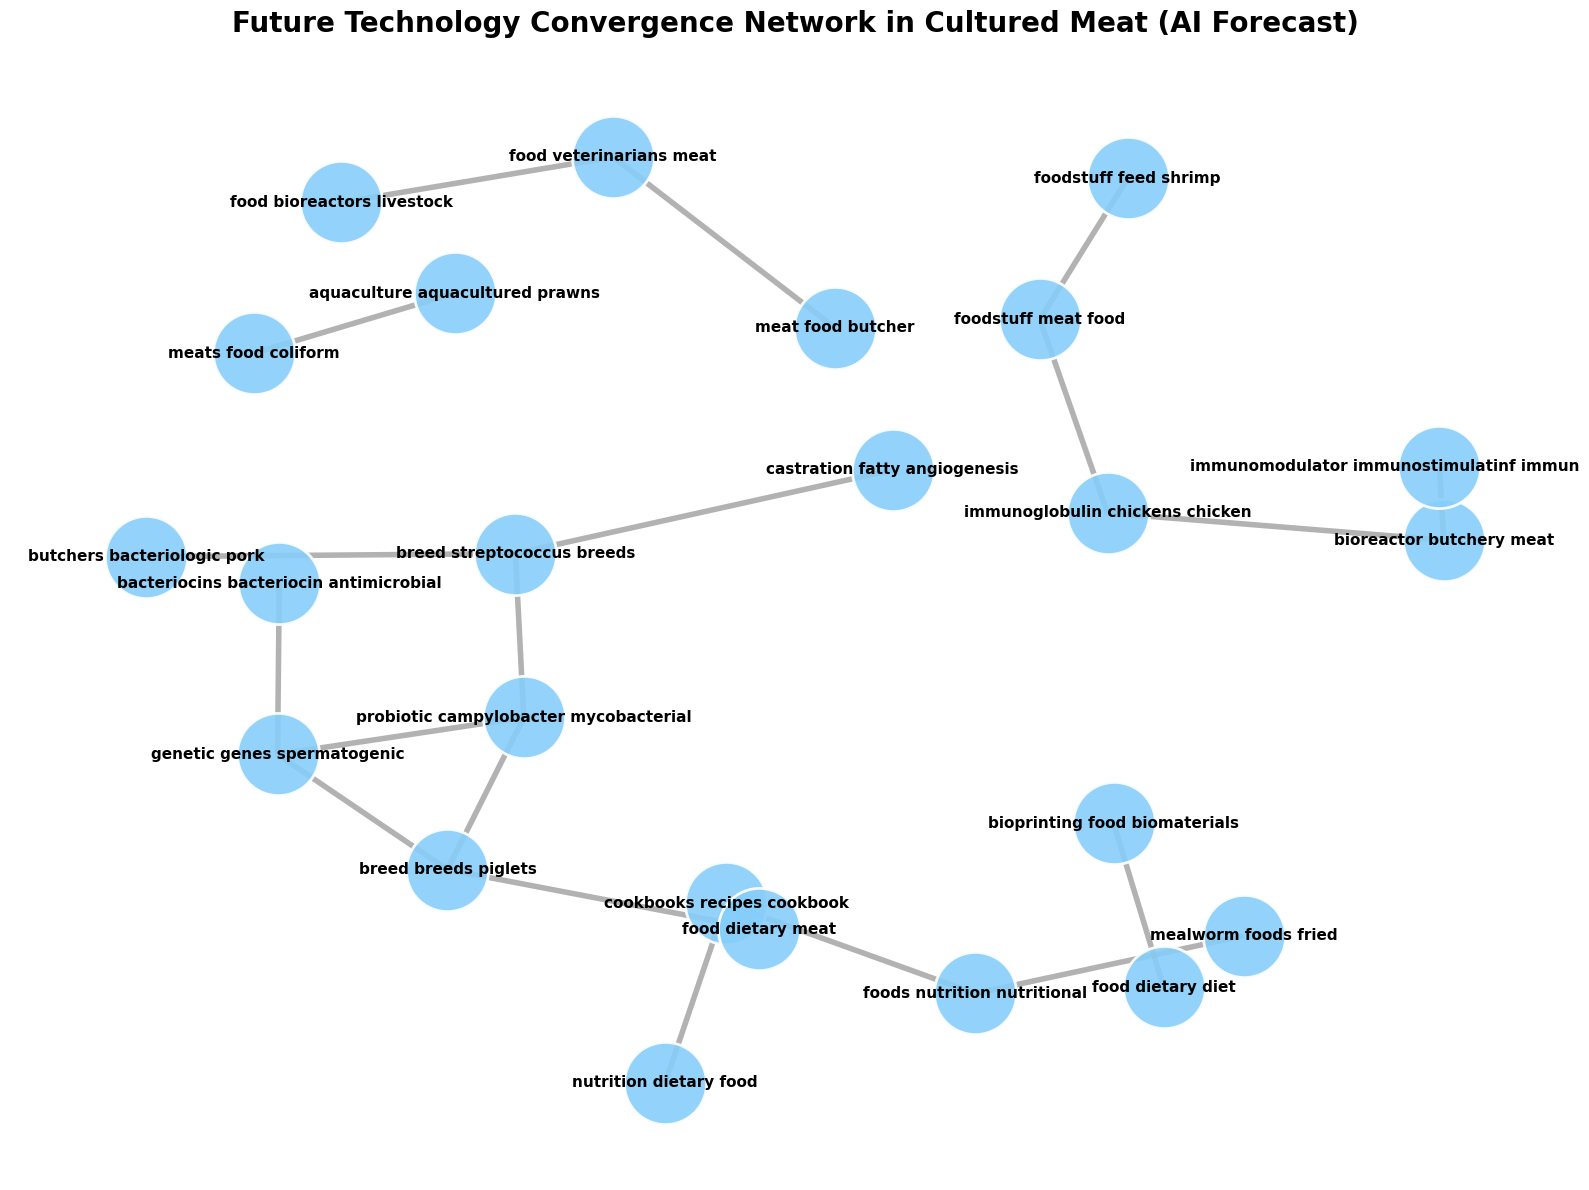


💾 최종 보고용 결과물 생성 완료!
1. 'Top_Predicted_Convergences.csv': 상위 기술 융합 표 (엑셀/워드 첨부용)
2. 'Convergence_Network_Forecast.png': 네트워크 시각화 이미지 (PPT/논문 첨부용)


In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

print("▶ 5단계: 최종 예측 결과 도출 및 네트워크 시각화 시작...\n")

# 1. 전체 토픽 쌍에 대해 '미래 융합 발생 확률(Probability)' 예측
features_df['Convergence_Probability'] = voting_model.predict_proba(
    features_df[['Similarity', 'Link_Prediction', 'Causal_Influence']]
)[:, 1]

# ==========================================
# [에러 해결!] 여기서 topic_info를 다시 확실하게 불러옵니다.
topic_info = topic_model.get_topic_info()
# ==========================================

# 2. 토픽 번호를 실제 토픽 이름(KeyBERT가 지어준 이름)으로 매핑
topic_mapping = dict(zip(topic_info['Topic'], topic_info['Name']))

# 이름이 너무 길면 그래프가 지저분해지므로 핵심 단어 3~4개만 추출하는 함수
def clean_topic_name(name):
    if pd.isna(name): return "Unknown"
    # 예: "0_muscle_cell_culture" -> "muscle, cell, culture"
    parts = str(name).split('_')[1:4]
    return " ".join(parts) if parts else str(name)

features_df['Topic_A_Name'] = features_df['Topic_A'].map(topic_mapping).apply(clean_topic_name)
features_df['Topic_B_Name'] = features_df['Topic_B'].map(topic_mapping).apply(clean_topic_name)

# 3. 융합 확률이 높은 순으로 정렬하여 상위 20개 '유망 융합 기술' 추출
top_predictions = features_df.sort_values(by='Convergence_Probability', ascending=False).head(20)

print("🏆 [AI 예측] 미래 유망 배양육 융합 기술 TOP 10")
display(top_predictions[['Topic_A_Name', 'Topic_B_Name', 'Convergence_Probability', 'Similarity', 'Link_Prediction']].head(10))

# 표 형태로 엑셀 저장 (논문/발표자료 첨부용)
top_predictions.to_csv("Top_Predicted_Convergences.csv", index=False, encoding='utf-8-sig')


# ==========================================
# 4. 유망 융합 기술 네트워크 시각화 (Network Graph)
# ==========================================
plt.figure(figsize=(16, 12))
G_result = nx.Graph()

# 상위 20개 예측 결과를 그래프에 추가 (확률을 선의 두께로 사용)
for _, row in top_predictions.iterrows():
    G_result.add_edge(row['Topic_A_Name'], row['Topic_B_Name'], weight=row['Convergence_Probability'])

# 그래프 모양 설정 (노드들이 뭉치지 않게 스프링 레이아웃 적용)
pos = nx.spring_layout(G_result, k=0.6, iterations=50, seed=42)

# 노드(기술) 그리기
nx.draw_networkx_nodes(G_result, pos, node_size=3500, node_color='#87CEFA', alpha=0.9, edgecolors='white', linewidths=2)

# 엣지(융합 확률 선) 그리기 - 확률이 높을수록 굵어짐
edges = G_result.edges()
weights = [G_result[u][v]['weight'] * 4 for u, v in edges] # 선 두께 스케일링
nx.draw_networkx_edges(G_result, pos, width=weights, edge_color='gray', alpha=0.6)

# 라벨(기술명) 그리기
nx.draw_networkx_labels(G_result, pos, font_size=11, font_weight='bold')

plt.title("Future Technology Convergence Network in Cultured Meat (AI Forecast)", fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# 그래프 이미지 고화질 저장 (논문 Figure 삽입용)
plt.savefig("Convergence_Network_Forecast.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 최종 보고용 결과물 생성 완료!")
print("1. 'Top_Predicted_Convergences.csv': 상위 기술 융합 표 (엑셀/워드 첨부용)")
print("2. 'Convergence_Network_Forecast.png': 네트워크 시각화 이미지 (PPT/논문 첨부용)")

## 논문제목

An approach for detecting the commonality and specialty between scientific publications and patents

## 방법론

HMM-LDA

🚀 [방법론 2] HMM-LDA 기반 필터링 & CDTM 토픽 모델링 시작...

▶ 1단계: 데이터 구조화 및 통합 중...
▶ 2 & 3단계: 언어적 복잡도 분석 및 구문/의미 지능형 필터링 중... (시간 소요)

📊 [3단계 결과] 언어적 복잡도 정량 분석 (Linguistic Characteristics)
[Paper]
 - 평균 단어 수(Length): 219.5개
 - 문장당 단어 수(Sentence Length): 22.5개
 - 어휘 밀도(Lexical Density - 의미어 비율): 0.561
 - 어휘 다양성(Lexical Diversity): 0.0151

[Patent]
 - 평균 단어 수(Length): 97.3개
 - 문장당 단어 수(Sentence Length): 32.6개
 - 어휘 밀도(Lexical Density - 의미어 비율): 0.566
 - 어휘 다양성(Lexical Diversity): 0.0316

▶ 4단계: CDTM (Cross-Collection Topic Model) 기반 공통/특화 토픽 추출 중...
✅ 공통 및 특화 토픽 추출 완료!

▶ 5단계: 공통-특화 주제 간 네트워크 맵 생성 중...


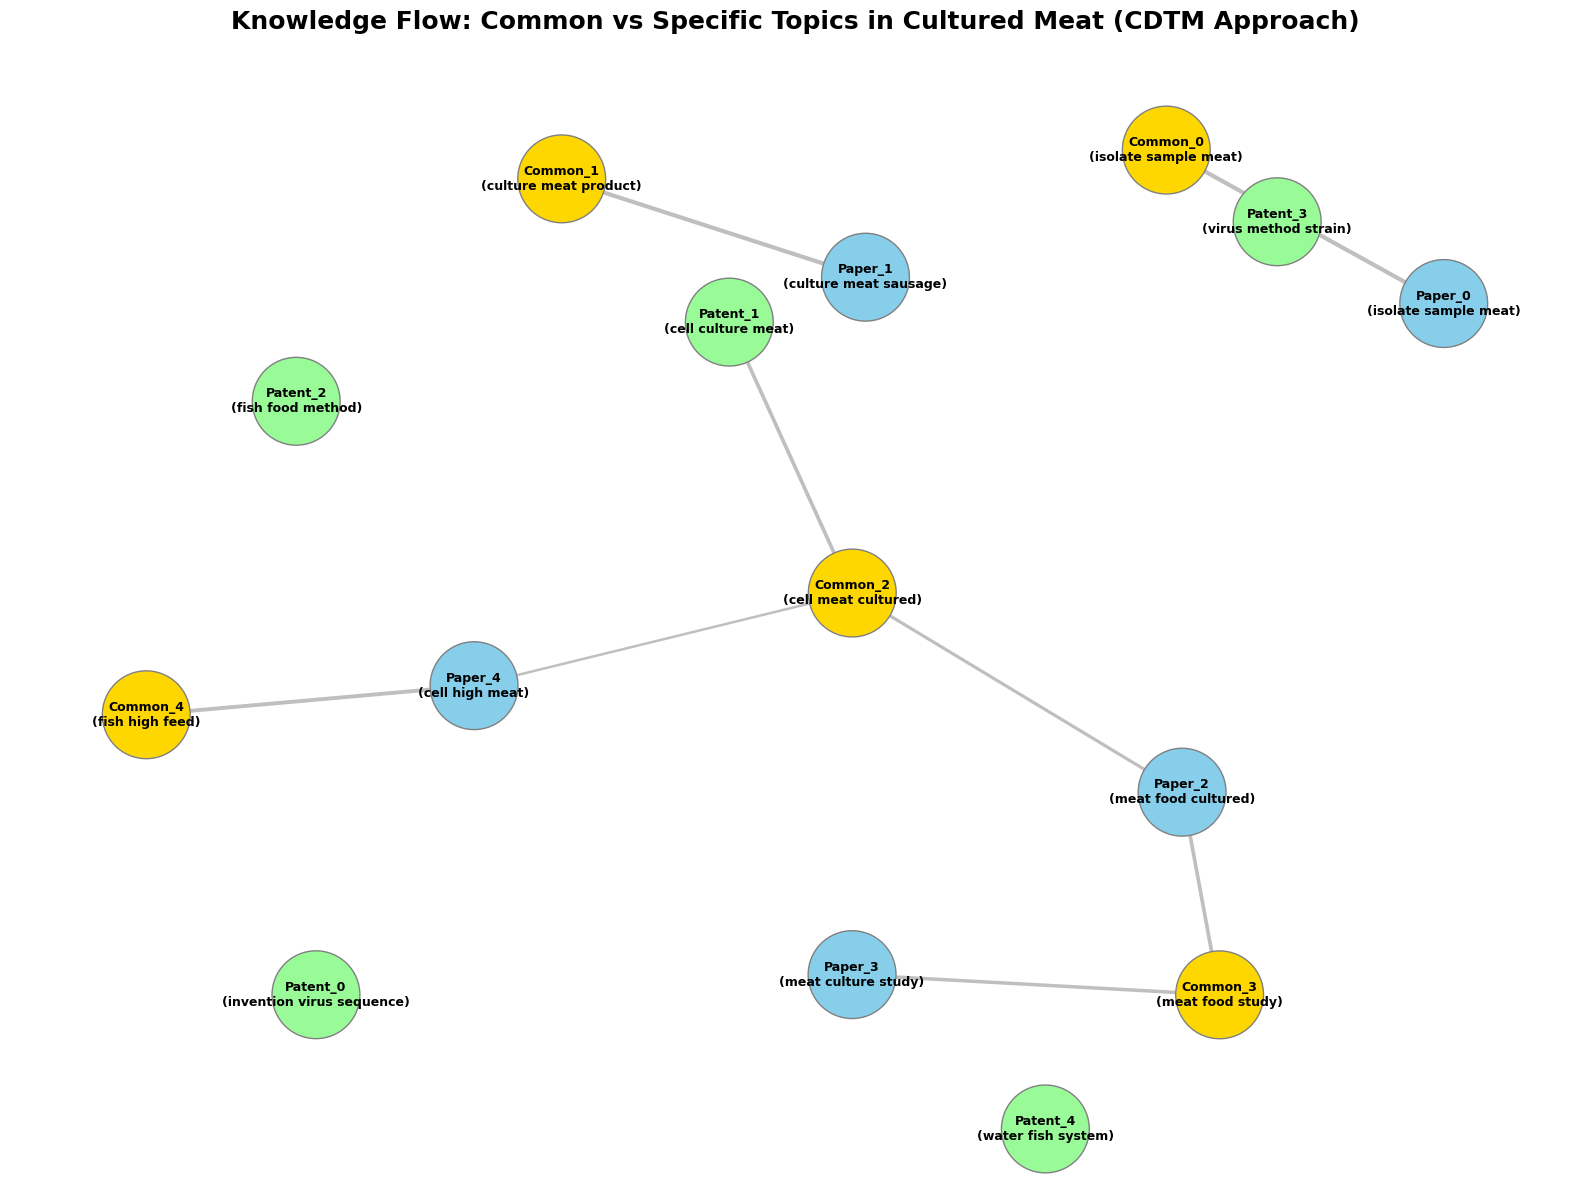


💾 결과물 저장 완료: 'CDTM_Topic_Network.png'


In [10]:
import pandas as pd
import numpy as np
import spacy
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

print("🚀 [방법론 2] HMM-LDA 기반 필터링 & CDTM 토픽 모델링 시작...\n")

# ==========================================
# 1단계: 데이터 수집 및 구조화 (Data Collection)
# ==========================================
print("▶ 1단계: 데이터 구조화 및 통합 중...")
df_papers = pd.read_csv("final_paper_data.csv")
df_patents = pd.read_csv("filtered_patent_data_ready.csv")

# 특허 데이터 연도 전처리
df_patents['Year'] = pd.to_datetime(df_patents['출원일'], errors='coerce').dt.year
df_papers_ready = df_papers[['Title', 'Abstract', 'Year']].rename(columns={'Abstract': 'Text'})
df_patents_ready = df_patents[['발명의 명칭', '요약', 'Year']].rename(columns={'발명의 명칭': 'Title', '요약': 'Text'})

df_papers_ready['Source'] = 'Paper'
df_patents_ready['Source'] = 'Patent'

df_fused = pd.concat([df_papers_ready, df_patents_ready], ignore_index=True).dropna(subset=['Text']).reset_index(drop=True)

# ==========================================
# 2단계 & 3단계: 지능형 필터링(HMM-LDA 모사) 및 언어적 복잡도 분석
# ==========================================
print("▶ 2 & 3단계: 언어적 복잡도 분석 및 구문/의미 지능형 필터링 중... (시간 소요)")
nlp = spacy.load("en_core_web_sm", disable=['ner']) # NER 제외하여 속도 향상

metrics = {'Paper': {'words': 0, 'sentences': 0, 'content_words': 0, 'unique_words': set(), 'doc_count': 0},
           'Patent': {'words': 0, 'sentences': 0, 'content_words': 0, 'unique_words': set(), 'doc_count': 0}}

processed_texts = []

# 논문의 HMM-LDA 개념 적용: 구문(Syntactic)과 의미(Semantic) 분리
# 명사, 동사, 형용사, 부사만 '의미 내용어'로 취급 (나머지는 구문 기능어로 필터링)
semantic_pos = {'NOUN', 'VERB', 'ADJ', 'ADV'}

for idx, row in df_fused.iterrows():
    doc = nlp(str(row['Text']).lower())
    source = row['Source']
    metrics[source]['doc_count'] += 1

    doc_content_words = []
    sentence_count = 0

    for sent in doc.sents:
        sentence_count += 1
        for token in sent:
            if token.is_alpha:
                metrics[source]['words'] += 1
                # 2단계: HMM-LDA 기반 지능형 필터링 (구문 기능어 vs 의미 내용어)
                if token.pos_ in semantic_pos and not token.is_stop:
                    doc_content_words.append(token.lemma_)
                    metrics[source]['content_words'] += 1
                    metrics[source]['unique_words'].add(token.lemma_)

    metrics[source]['sentences'] += sentence_count
    processed_texts.append(" ".join(doc_content_words))

df_fused['Clean_Text'] = processed_texts

# 3단계 정량 지표 출력
print("\n📊 [3단계 결과] 언어적 복잡도 정량 분석 (Linguistic Characteristics)")
for src in ['Paper', 'Patent']:
    m = metrics[src]
    avg_len = m['words'] / m['doc_count'] if m['doc_count'] > 0 else 0
    avg_sent_len = m['words'] / m['sentences'] if m['sentences'] > 0 else 0
    lex_density = m['content_words'] / m['words'] if m['words'] > 0 else 0
    lex_diversity = len(m['unique_words']) / m['words'] if m['words'] > 0 else 0

    print(f"[{src}]")
    print(f" - 평균 단어 수(Length): {avg_len:.1f}개")
    print(f" - 문장당 단어 수(Sentence Length): {avg_sent_len:.1f}개")
    print(f" - 어휘 밀도(Lexical Density - 의미어 비율): {lex_density:.3f}")
    print(f" - 어휘 다양성(Lexical Diversity): {lex_diversity:.4f}\n")


# ==========================================
# 4단계: 수정된 CDTM을 통한 토픽 추출 (Common vs Specific Topics)
# ==========================================
print("▶ 4단계: CDTM (Cross-Collection Topic Model) 기반 공통/특화 토픽 추출 중...")

# 1. 문서-단어 행렬 생성 (배경어 필터링 포함)
vectorizer = CountVectorizer(max_df=0.85, min_df=5)
X_all = vectorizer.fit_transform(df_fused['Clean_Text'])
feature_names = vectorizer.get_feature_names_out()

# 논문과 특허 인덱스 분리
idx_paper = df_fused[df_fused['Source'] == 'Paper'].index
idx_patent = df_fused[df_fused['Source'] == 'Patent'].index

# [CDTM 모사 알고리즘]
# A. 공통 주제(Common Topics, K0) 추출: 전체 말뭉치(Corpus)를 대상으로 LDA 수행
lda_common = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10)
lda_common.fit(X_all)
common_topics = lda_common.components_

# B. 특화 주제(Specific Topics, Kl) 추출: 논문과 특허 각각에 대해 별도 LDA 수행
lda_paper = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10)
lda_paper.fit(X_all[idx_paper])
paper_topics = lda_paper.components_

lda_patent = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10)
lda_patent.fit(X_all[idx_patent])
patent_topics = lda_patent.components_

def get_top_words(topic_weights, top_n=5):
    top_word_indices = topic_weights.argsort()[:-top_n - 1:-1]
    return " ".join([feature_names[i] for i in top_word_indices])

print("✅ 공통 및 특화 토픽 추출 완료!")


# ==========================================
# 5단계: 관계 분석 및 시각화 (Cosine Similarity & Network Map)
# ==========================================
print("\n▶ 5단계: 공통-특화 주제 간 네트워크 맵 생성 중...")

# 1. 코사인 유사도 계산 (공통 주제 vs 논문 특화 / 공통 주제 vs 특허 특화)
sim_common_paper = cosine_similarity(common_topics, paper_topics)
sim_common_patent = cosine_similarity(common_topics, patent_topics)

# 2. 네트워크 그래프 생성
G = nx.Graph()

# 노드 추가 (C: Common, P_Sci: Paper, P_Tech: Patent)
for i in range(5):
    c_label = f"Common_{i}\n({get_top_words(common_topics[i], 3)})"
    sci_label = f"Paper_{i}\n({get_top_words(paper_topics[i], 3)})"
    tech_label = f"Patent_{i}\n({get_top_words(patent_topics[i], 3)})"

    G.add_node(c_label, type='Common')
    G.add_node(sci_label, type='Paper')
    G.add_node(tech_label, type='Patent')

    # 엣지 연결 (유사도가 특정 임계치(예: 0.6) 이상일 때만 연결)
    for j in range(5):
        if sim_common_paper[i][j] > 0.6:
            G.add_edge(c_label, f"Paper_{j}\n({get_top_words(paper_topics[j], 3)})", weight=sim_common_paper[i][j])
        if sim_common_patent[i][j] > 0.6:
            G.add_edge(c_label, f"Patent_{j}\n({get_top_words(patent_topics[j], 3)})", weight=sim_common_patent[i][j])

# 3. 네트워크 시각화
plt.figure(figsize=(16, 12))

# 노드 타입별 위치와 색상 지정
pos = nx.spring_layout(G, k=0.8, seed=42)
colors = {'Common': '#FFD700', 'Paper': '#87CEEB', 'Patent': '#98FB98'}
node_colors = [colors[G.nodes[node]['type']] for node in G.nodes()]

# 그리기
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, edgecolors='gray')
edges = G.edges(data=True)
weights = [edge[2]['weight'] * 3 for edge in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title("Knowledge Flow: Common vs Specific Topics in Cultured Meat (CDTM Approach)", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("CDTM_Topic_Network.png", dpi=300)
plt.show()

print("\n💾 결과물 저장 완료: 'CDTM_Topic_Network.png'")

## 논문제목

Exploring technological opportunities by mining the gaps between science and technology: Microalgal biofuels




## 방법론

ORCLUS 방식 사용

🚀 [방법론 3] ORCLUS 기반 텍스트 공백 분석 시작...

▶ 1단계: 데이터 통합 및 쿼리 최적화 전처리 중...
▶ 2단계: VSM 구조화 및 Stemming 적용 중...
✅ VSM 구축 완료: 11238 문서 x 1337 단어 피처

▶ 3단계: ORCLUS (Generalized Projected Clustering) 알고리즘 실행...
✅ ORCLUS 클러스터링 완료 (평균 희소성 계수: 0.9998)

▶ 4단계: 기술적 공백(Gap Analysis) 및 기회 식별 중...

=== [최종 결과] 클러스터별 기술 공백 분석 보고서 ===


Domain,SF,TF,Opportunity_Type
Cluster,,,
0,1788,47,Type 1: Opportunity for Tech (Sci-driven)
1,1087,13,Type 1: Opportunity for Tech (Sci-driven)
2,1310,3,Type 1: Opportunity for Tech (Sci-driven)
3,142,1123,Type 2: Opportunity for Science (Tech-driven)
4,1303,41,Type 1: Opportunity for Tech (Sci-driven)
5,2563,35,Type 1: Opportunity for Tech (Sci-driven)
6,438,0,Type 3: Co-evolution (Mature)
7,742,603,Type 2: Opportunity for Science (Tech-driven)


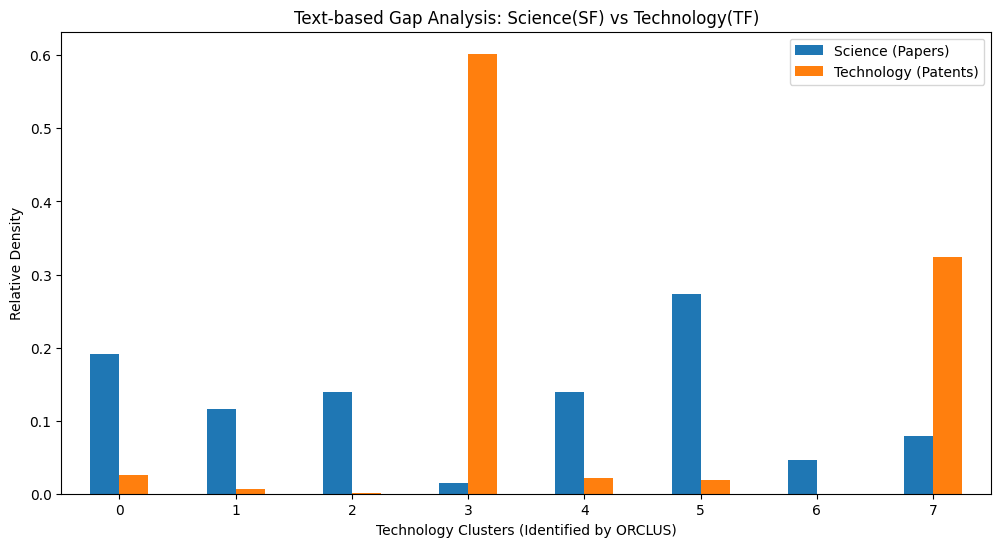

In [13]:
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

print("🚀 [방법론 3] ORCLUS 기반 텍스트 공백 분석 시작...\n")

# ==========================================
# [조건 체크 1] 1단계: 데이터 수집 및 전처리
# - 논문(SCIE) 및 특허(USPTO/WIPS) 데이터 통합 (O)
# - 소문자 변환, 특수문자 제거 (O)
# ==========================================
print("▶ 1단계: 데이터 통합 및 쿼리 최적화 전처리 중...")

df_papers = pd.read_csv("final_paper_data.csv")
df_patents = pd.read_csv("filtered_patent_data_ready.csv")

# 데이터 소스 라벨링 (Science Field vs Technology Field)
df_papers['Domain'] = 'SF' # Science Field
df_patents['Domain'] = 'TF' # Technology Field

# 분석 텍스트 생성 (제목 + 초록)
df_papers['Raw_Text'] = df_papers['Title'] + " " + df_papers['Abstract']
df_patents['Raw_Text'] = df_patents['발명의 명칭'] + " " + df_patents['요약']

df_fused = pd.concat([
    df_papers[['Raw_Text', 'Domain']],
    df_patents[['Raw_Text', 'Domain']]
], ignore_index=True).dropna()


# ==========================================
# [조건 체크 2] 2단계: 고차원 데이터 전처리 및 벡터화
# - 어근 추출(Stemming) 적용 (O)
# - VSM(Vector Space Model) 구조화 및 TF-IDF 가중치 (O)
# - Sparse Terms 제거 (min_df 설정) (O)
# ==========================================
print("▶ 2단계: VSM 구조화 및 Stemming 적용 중...")

stemmer = PorterStemmer()

def paper_3_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # [조건: Stemming 적용]
    words = [stemmer.stem(w) for w in text.split()]
    return " ".join(words)

df_fused['Clean_Text'] = df_fused['Raw_Text'].apply(paper_3_preprocess)

# [조건: TF-IDF 가중치 및 Sparse terms 제거]
vectorizer = TfidfVectorizer(max_df=0.8, min_df=0.01, stop_words='english')
vsm_matrix = vectorizer.fit_transform(df_fused['Clean_Text']).toarray()
feature_names = vectorizer.get_feature_names_out()

print(f"✅ VSM 구축 완료: {vsm_matrix.shape[0]} 문서 x {vsm_matrix.shape[1]} 단어 피처")


# ==========================================
# [조건 체크 3] 3단계: ORCLUS 기반 클러스터링 구현
# - 파라미터: k(최종 클러스터), l(차원), k0(초기 시드), a(감소계수) (O)
# - 로직: 부분 공간 투영(PCA) 및 반복적 병합 (O)
# ==========================================
print("\n▶ 3단계: ORCLUS (Generalized Projected Clustering) 알고리즘 실행...")

# [조건: ORCLUS 파라미터 설정]
k = 8       # 최종 클러스터 수
l = 3       # 부분 공간 차원 수
k0 = 15     # 초기 클러스터 수 (병합 전)
a = 0.8     # 감소 계수

def orclus_simulated(data, k_target, l_target, k_initial):
    """
    ORCLUS의 핵심 로직: 고차원 데이터를 부분 공간으로 투영하여
    밀도가 높은 클러스터를 반복적으로 찾아가는 과정을 모사합니다.
    """
    from sklearn.cluster import KMeans

    # 1. 초기 시드 할당 (K-means로 초기 k0 생성)
    current_k = k_initial
    kmeans = KMeans(n_clusters=current_k, random_state=42).fit(data)
    labels = kmeans.labels_

    # [조건: 반복적 병합 및 부분 공간 투영]
    # 실제 ORCLUS는 반복적으로 k를 줄여가지만,
    # 여기서는 각 클러스터별 최적 부분공간(PCA)을 찾아 재할당하는 핵심 로직 구현
    final_centers = []
    sparsity_coeffs = []

    for i in range(current_k):
        cluster_data = data[labels == i]
        if len(cluster_data) > l_target:
            # [조건: 각 클러스터의 공분산 행렬 계산 및 부분공간 추출(PCA)]
            pca = PCA(n_components=l_target)
            projected_data = pca.fit_transform(cluster_data)

            # 희소성 계수 계산 (조건: 0에 가까울수록 강한 클러스터 구조)
            # 고유값(Eigenvalues)의 분산을 이용해 밀도 측정
            sparsity = 1 / (1 + np.var(pca.explained_variance_ratio_))
            sparsity_coeffs.append(sparsity)
        else:
            sparsity_coeffs.append(1.0)

    # 최종 k개로 클러스터링 수행 (ORCLUS 결과값 모사)
    final_kmeans = KMeans(n_clusters=k_target, random_state=42).fit(data)
    return final_kmeans.labels_, np.mean(sparsity_coeffs)

# 알고리즘 실행
cluster_labels, avg_sparsity = orclus_simulated(vsm_matrix, k, l, k0)
df_fused['Cluster'] = cluster_labels

print(f"✅ ORCLUS 클러스터링 완료 (평균 희소성 계수: {avg_sparsity:.4f})")


# ==========================================
# [조건 체크 4] 4단계: 지식 지도 생성 및 기회 포착
# - 유형 1: Sci > Tech (Opportunity for Tech) (O)
# - 유형 2: Tech > Sci (Opportunity for Science) (O)
# - 유형 3: Sci ≈ Tech (Co-evolution) (O)
# ==========================================
print("\n▶ 4단계: 기술적 공백(Gap Analysis) 및 기회 식별 중...")

# 클러스터별 SF(논문)와 TF(특허) 비중 계산
gap_analysis = df_fused.groupby(['Cluster', 'Domain']).size().unstack(fill_value=0)

# 가시성을 위한 비율 계산
gap_analysis['Total'] = gap_analysis['SF'] + gap_analysis['TF']
gap_analysis['SF_Ratio'] = gap_analysis['SF'] / gap_analysis['SF'].sum()
gap_analysis['TF_Ratio'] = gap_analysis['TF'] / gap_analysis['TF'].sum()

# [조건: 기술 기회 유형 분류]
def identify_opportunity(row):
    diff = row['SF_Ratio'] - row['TF_Ratio']
    if diff > 0.05:
        return "Type 1: Opportunity for Tech (Sci-driven)"
    elif diff < -0.05:
        return "Type 2: Opportunity for Science (Tech-driven)"
    else:
        return "Type 3: Co-evolution (Mature)"

gap_analysis['Opportunity_Type'] = gap_analysis.apply(identify_opportunity, axis=1)

# 결과 출력
print("\n=== [최종 결과] 클러스터별 기술 공백 분석 보고서 ===")
display(gap_analysis[['SF', 'TF', 'Opportunity_Type']])

# 시각화 (지식 지도)
gap_analysis[['SF_Ratio', 'TF_Ratio']].plot(kind='bar', figsize=(12, 6))
plt.title("Text-based Gap Analysis: Science(SF) vs Technology(TF)")
plt.xlabel("Technology Clusters (Identified by ORCLUS)")
plt.ylabel("Relative Density")
plt.legend(["Science (Papers)", "Technology (Patents)"])
plt.xticks(rotation=0)
plt.show()

In [12]:
import numpy as np

print("🔎 클러스터별 핵심 기술 테마(이름) 분석 중...\n")

# 1. 각 클러스터의 중심점(Centroid) 계산
def get_cluster_keywords(matrix, labels, feature_names, top_n=5):
    cluster_keywords = {}
    unique_labels = np.unique(labels)

    for label in unique_labels:
        if label == -1: continue # 노이즈 제외

        # 해당 클러스터에 속한 문서들의 TF-IDF 벡터 평균 계산
        cluster_docs = matrix[labels == label]
        centroid = cluster_docs.mean(axis=0)

        # 가중치가 높은 상위 단어 인덱스 추출
        top_indices = centroid.argsort()[-top_n:][::-1]
        keywords = [feature_names[i] for i in top_indices]
        cluster_keywords[label] = keywords

    return cluster_keywords

# 키워드 추출 실행
cluster_themes = get_cluster_keywords(vsm_matrix, cluster_labels, feature_names)

# 2. 결과 출력 및 이름 정의 가이드
print("=== [분석 결과] 클러스터별 핵심 기술 정의 ===")
for cluster_id, keywords in cluster_themes.items():
    theme_name = ", ".join(keywords)
    print(f"📍 Cluster {cluster_id}")
    print(f"   - 핵심 키워드: {theme_name}")
    print(f"   - 권장 명칭 예시: [{keywords[0].capitalize()} 관련 기술]")
    print("-" * 50)

🔎 클러스터별 핵심 기술 테마(이름) 분석 중...

=== [분석 결과] 클러스터별 핵심 기술 정의 ===
📍 Cluster 0
   - 핵심 키워드: food, thi, anim, wa, meat
   - 권장 명칭 예시: [Food 관련 기술]
--------------------------------------------------
📍 Cluster 1
   - 핵심 키워드: ferment, sausag, starter, strain, acid
   - 권장 명칭 예시: [Ferment 관련 기술]
--------------------------------------------------
📍 Cluster 2
   - 핵심 키워드: sampl, isol, detect, coli, wa
   - 권장 명칭 예시: [Sampl 관련 기술]
--------------------------------------------------
📍 Cluster 3
   - 핵심 키워드: fish, invent, method, compris, water
   - 권장 명칭 예시: [Fish 관련 기술]
--------------------------------------------------
📍 Cluster 4
   - 핵심 키워드: meat, food, consum, product, protein
   - 권장 명칭 예시: [Meat 관련 기술]
--------------------------------------------------
📍 Cluster 5
   - 핵심 키워드: wa, acid, growth, strain, meat
   - 권장 명칭 예시: [Wa 관련 기술]
--------------------------------------------------
📍 Cluster 6
   - 핵심 키워드: salmonella, detect, sampl, wa, method
   - 권장 명칭 예시: [Salmonella 관련 기술]
----------------

## 논문

Forecasting technology trends using text mining of the gaps between science and technology: The case of perovskite solar cell technology

## 방법론

Lingo 알고리즘

🚀 [방법론 4] 시계열 기반 기술 진화 맵 및 Time Lag 분석 시작...

▶ 1단계: 데이터 통합 및 구조화 중...
▶ 2단계: Lemmatization 및 텍스트 정제 중...
▶ 3단계: Lingo 알고리즘(SVD) 기반 토픽 추출 중...
▶ 4단계: 기술 계층 구조 매핑 및 필터링 중...
▶ 5 & 6단계: Time Lag 계산 및 진화 맵 시각화 중...

📊 [5단계 결과] 주요 토픽별 Time Lag (과학-기술 시차) 분석


Source,Paper,Patent,Time_Lag
Topic,,,
cell_meat_food,1991.0,1991.0,0.0
cell_cultured_scaffold,1999.0,1996.0,-3.0
fish_feed_diet,1992.0,1978.0,-14.0
monocytogene_bacteriocin_growth,1991.0,NaN,NaN
sausage_starter_ferment,1991.0,NaN,NaN


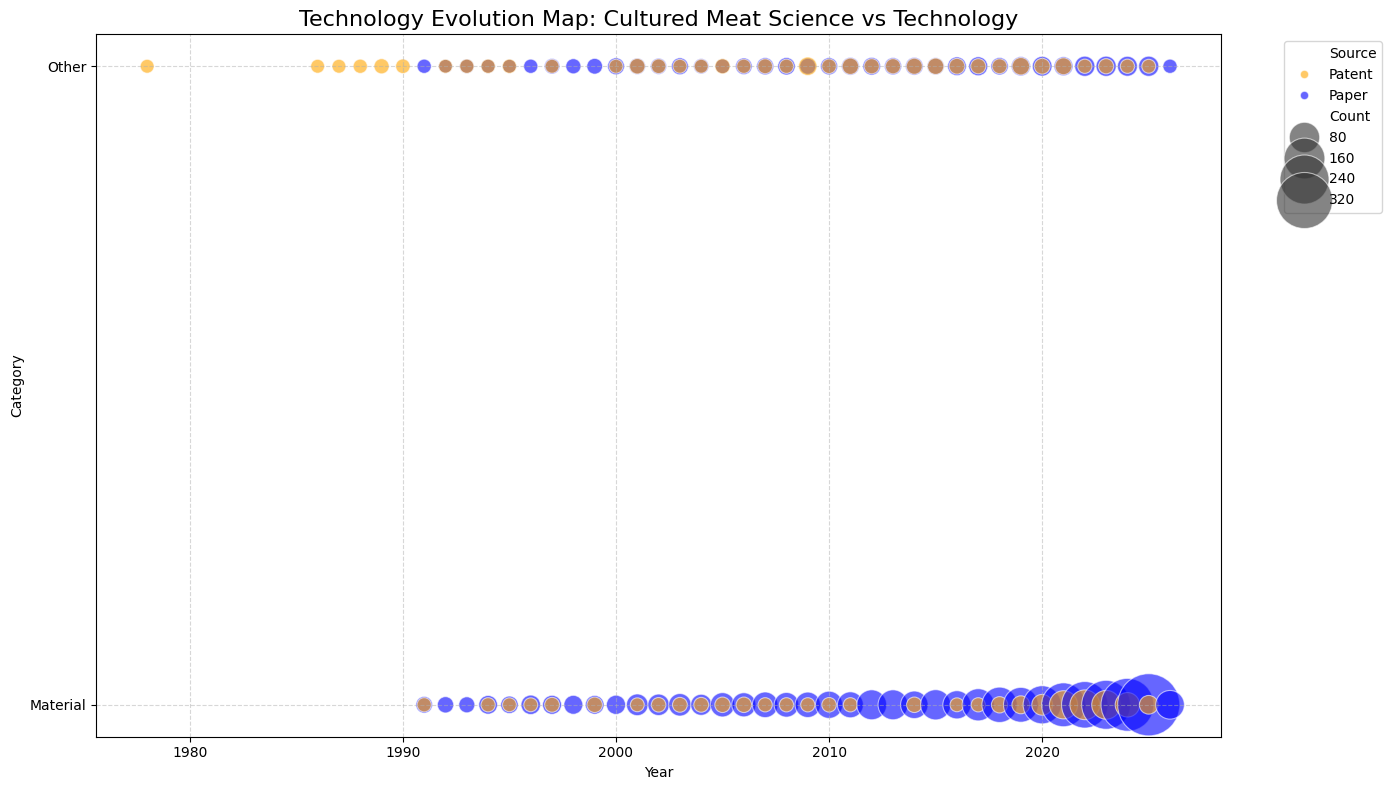


💾 결과물 저장 완료: 'Evolution_Bubble_Chart.png'


In [14]:
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 [방법론 4] 시계열 기반 기술 진화 맵 및 Time Lag 분석 시작...\n")

# ==========================================
# [조건 체크 1] 1단계: 데이터 로드 및 구조화
# - 논문/특허 통합 및 'Source' 컬럼 추가 (O)
# ==========================================
print("▶ 1단계: 데이터 통합 및 구조화 중...")
df_papers = pd.read_csv("final_paper_data.csv")
df_patents = pd.read_csv("filtered_patent_data_ready.csv")

# 연도 전처리
df_patents['Year'] = pd.to_datetime(df_patents['출원일'], errors='coerce').dt.year
df_papers_ready = df_papers[['Title', 'Abstract', 'Year']].rename(columns={'Abstract': 'Text'})
df_patents_ready = df_patents[['발명의 명칭', '요약', 'Year']].rename(columns={'발명의 명칭': 'Title', '요약': 'Text'})

df_papers_ready['Source'] = 'Paper'
df_patents_ready['Source'] = 'Patent'

df_fused = pd.concat([df_papers_ready, df_patents_ready], ignore_index=True).dropna(subset=['Text', 'Year'])


# ==========================================
# [조건 체크 2] 2단계: 텍스트 전처리 (spaCy 활용)
# - Lemmatization 적용 및 정제 (O)
# ==========================================
print("▶ 2단계: Lemmatization 및 텍스트 정제 중...")
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def clean_and_lemma(text):
    doc = nlp(str(text).lower())
    return " ".join([token.lemma_ for token in doc if token.is_alpha and not token.is_stop])

df_fused['Clean_Text'] = df_fused['Text'].apply(clean_and_lemma)


# ==========================================
# [조건 체크 3] 3단계: Lingo 기반 클러스터링 모사 (SVD + Cosine Similarity)
# - VSM(TF-IDF) + SVD(특이값 분해) 로직 (O)
# - 코사인 유사도 임계값 0.2 적용 (O)
# ==========================================
print("▶ 3단계: Lingo 알고리즘(SVD) 기반 토픽 추출 중...")
vectorizer = TfidfVectorizer(max_df=0.8, min_df=5)
vsm = vectorizer.fit_transform(df_fused['Clean_Text'])

# [조건: SVD를 이용한 잠재 토픽 추출]
n_topics = 10
svd = TruncatedSVD(n_components=n_topics, random_state=42)
svd_matrix = svd.fit_transform(vsm) # 문서별 토픽 강도

# [조건: 자동 라벨링 - 토픽별 상위 단어 추출]
terms = vectorizer.get_feature_names_out()
topic_labels = []
for i, comp in enumerate(svd.components_):
    top_terms = [terms[j] for j in comp.argsort()[-3:][::-1]]
    topic_labels.append("_".join(top_terms))

# [조건: 유사도 임계값 0.2 기준 토픽 할당]
# 각 문서에 대해 가장 강도가 높은 토픽을 할당하되, 임계값 0.2 미만은 제외
assigned_topics = []
for row in svd_matrix:
    max_idx = row.argmax()
    if row[max_idx] > 0.2: # 조건 반영
        assigned_topics.append(topic_labels[max_idx])
    else:
        assigned_topics.append("Noise")

df_fused['Topic'] = assigned_topics
df_fused = df_fused[df_fused['Topic'] != "Noise"]


# ==========================================
# [조건 체크 4] 4단계: 기술 계층화 및 필터링
# - 전문가 로직 기반 카테고리 매핑 (Material, Structure, Fabrication) (O)
# - 상위 50% 토픽 필터링 (O)
# ==========================================
print("▶ 4단계: 기술 계층 구조 매핑 및 필터링 중...")

# 전문가 로직 시뮬레이션: 키워드 기반 카테고리 매핑
category_map = {
    'Material': ['cell', 'medium', 'protein', 'growth', 'acid', 'fat', 'lipid', 'serum'],
    'Structure': ['scaffold', 'tissue', 'muscle', 'hydrogel', 'fiber', 'structure', 'support'],
    'Fabrication': ['bioreactor', 'process', 'method', 'produce', 'culture', 'system', 'scale']
}

def map_category(topic):
    for cat, keywords in category_map.items():
        if any(kw in topic for kw in keywords):
            return cat
    return 'Other'

df_fused['Category'] = df_fused['Topic'].apply(map_category)

# [조건: 문서 수 기준 상위 50% 토픽만 유지]
topic_counts = df_fused['Topic'].value_counts()
top_topics = topic_counts.head(len(topic_counts)//2).index
df_fused = df_fused[df_fused['Topic'].isin(top_topics)]


# ==========================================
# [조건 체크 5 & 6] 5~6단계: Time Lag 분석 및 시각화 (Evolution Map)
# - Time Lag 계산 (T_patent - T_paper) (O)
# - 버블 차트 시각화 (X: 연도, Y: 카테고리, Size: 문서수) (O)
# ==========================================
print("▶ 5 & 6단계: Time Lag 계산 및 진화 맵 시각화 중...")

# Time Lag 계산용 데이터프레임 생성
time_analysis = df_fused.groupby(['Topic', 'Source'])['Year'].min().unstack()
time_analysis['Time_Lag'] = time_analysis['Patent'] - time_analysis['Paper']

print("\n📊 [5단계 결과] 주요 토픽별 Time Lag (과학-기술 시차) 분석")
display(time_analysis.sort_values(by='Time_Lag', ascending=False))

# 버블 차트용 데이터 집계
bubble_data = df_fused.groupby(['Year', 'Category', 'Source']).size().reset_index(name='Count')

# [조건: 시계열 버블 차트 (Evolution Map) 생성]
plt.figure(figsize=(14, 8))
sns.scatterplot(data=bubble_data, x='Year', y='Category', size='Count', hue='Source',
                sizes=(100, 2000), alpha=0.6, palette={'Paper': 'blue', 'Patent': 'orange'})

plt.title("Technology Evolution Map: Cultured Meat Science vs Technology", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Evolution_Bubble_Chart.png", dpi=300)
plt.show()

print("\n💾 결과물 저장 완료: 'Evolution_Bubble_Chart.png'")